In [108]:
%pip install xgboost lightgbm catboost mlflow torch seaborn matplotlib tensorflow keras

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.2 MB/s  0:10:28m0:00:0100:06m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 2.9 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 1.7 MB/s  0:00:03 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
  Attempting uninstall: tensorboard━━━━━━━━━━━━━ 0/3 [numpy]
    Found existing installation: tensorboard 2.20.032m0/3 [numpy]
    Uninstalling tensorboard-2.20.0:━━━━━━━━ 0/3 [numpy]
      Successfully uninstalled tensorboard-2.20.00/3 [numpy]
  Attempting uninstall: tensorflowm━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tensorboard]
    Found existing installation: tensorflow 2.20.0━━━━━━━━━━━━ 1/3 [tensorboard]
    Uninstalling tensorflow-2.20.0:

# Info

## Fields

### Target
price - Price of the Houses

### Features
area - Area of a House

bedrooms - Number of House Bedrooms

bathrooms - Number if Bathrooms

stories - Number of House Stories

mainroad - Weather connected to Main Road

guestroom - Weather has a guest room

basement - Weather has a basement

hotwaterheating - Weather has a hotwater heater

airconditioning - Weather has an airconditioning

parking - Number of House Parkings

prefarea - Prefarea of the House

furnishingstatus - Furnishing status of the House

# Import

In [55]:
import pandas as pd
import sklearn as sk
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import tensorflow
from tensorflow import keras

import joblib


## Data preparing

In [5]:
data = pd.read_csv(r'datas/Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
mp = {'no': 0, 'yes': 1, 'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0}
clas = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for i in clas:
    data[i] = data[i].map(mp)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1.0,0.0,0.0,0.0,1.0,2,1.0,1.0
1,12250000,8960,4,4,4,1.0,0.0,0.0,0.0,1.0,3,0.0,1.0
2,12250000,9960,3,2,2,1.0,0.0,1.0,0.0,0.0,2,1.0,0.5
3,12215000,7500,4,2,2,1.0,0.0,1.0,0.0,1.0,3,1.0,1.0
4,11410000,7420,4,1,2,1.0,1.0,1.0,0.0,1.0,2,0.0,1.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    float64
 6   guestroom         545 non-null    float64
 7   basement          545 non-null    float64
 8   hotwaterheating   545 non-null    float64
 9   airconditioning   545 non-null    float64
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    float64
 12  furnishingstatus  545 non-null    float64
dtypes: float64(7), int64(6)
memory usage: 55.5 KB


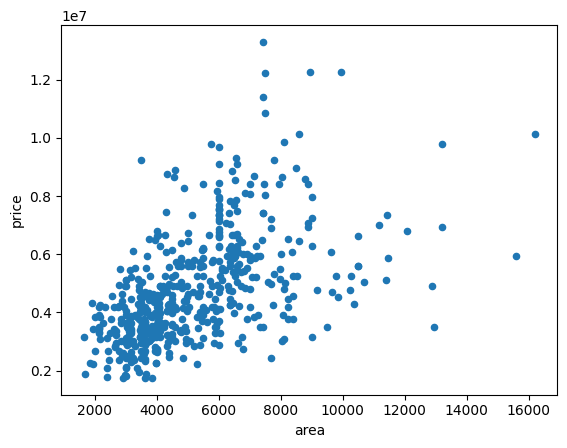

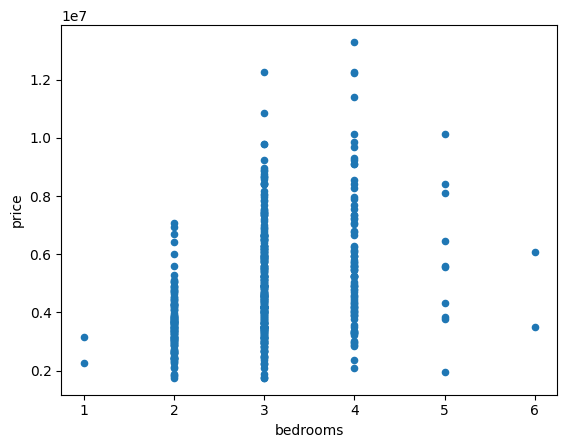

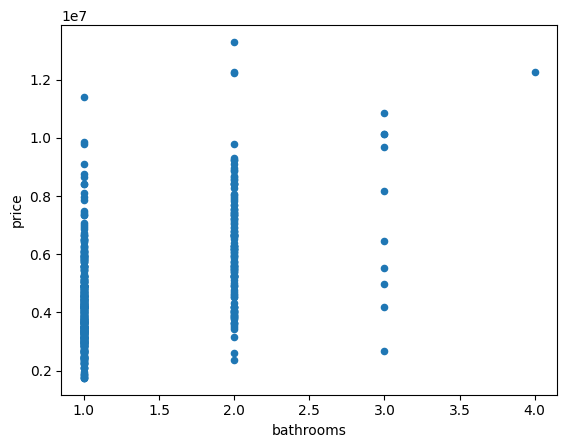

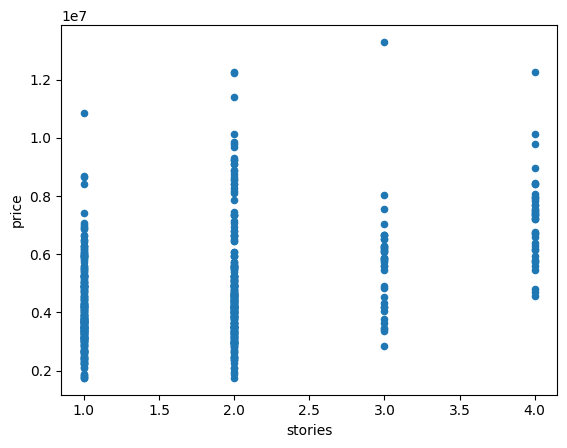

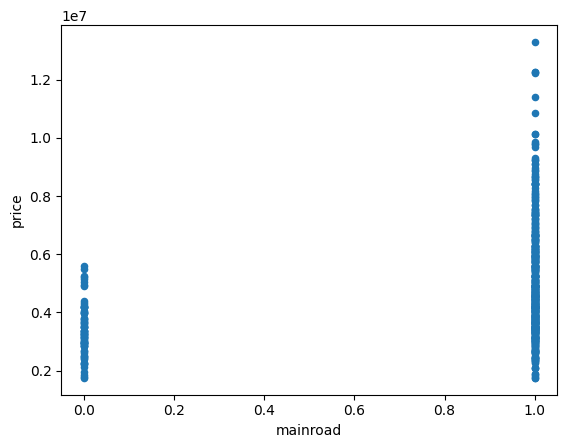

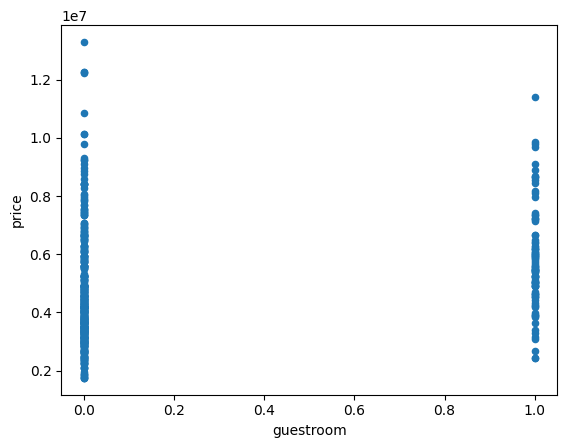

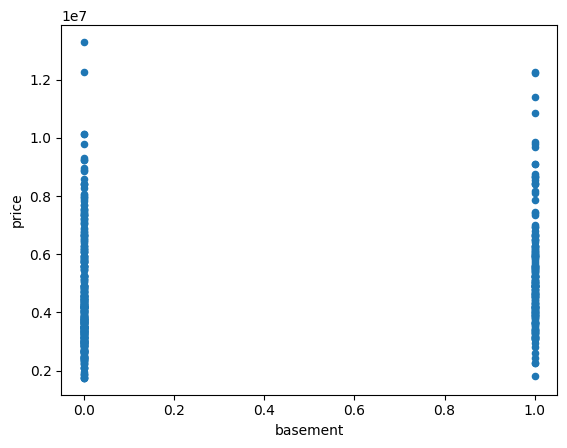

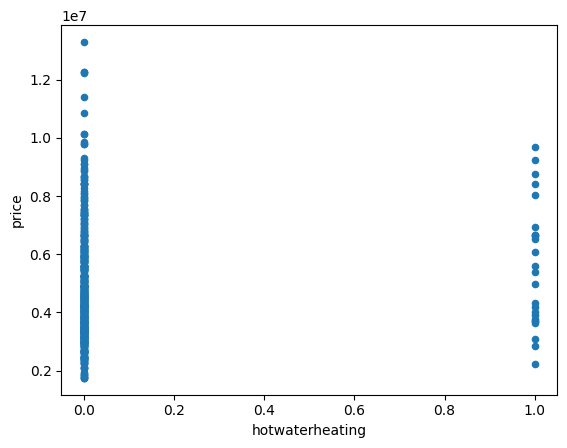

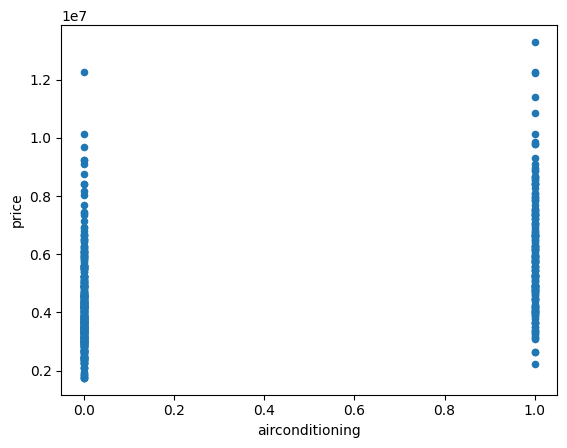

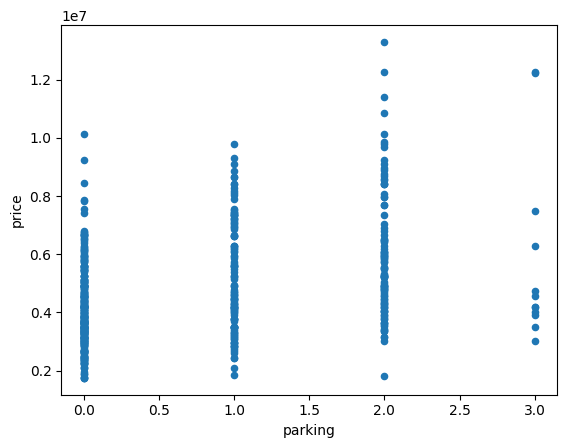

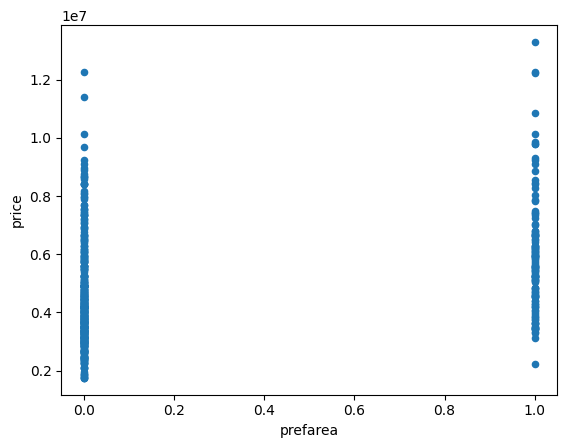

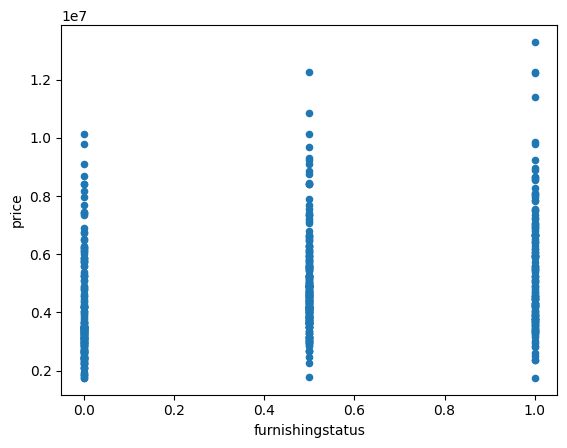

In [8]:
for c in data.columns[1:]:
    data.plot.scatter(c, 'price')
    plt.show()

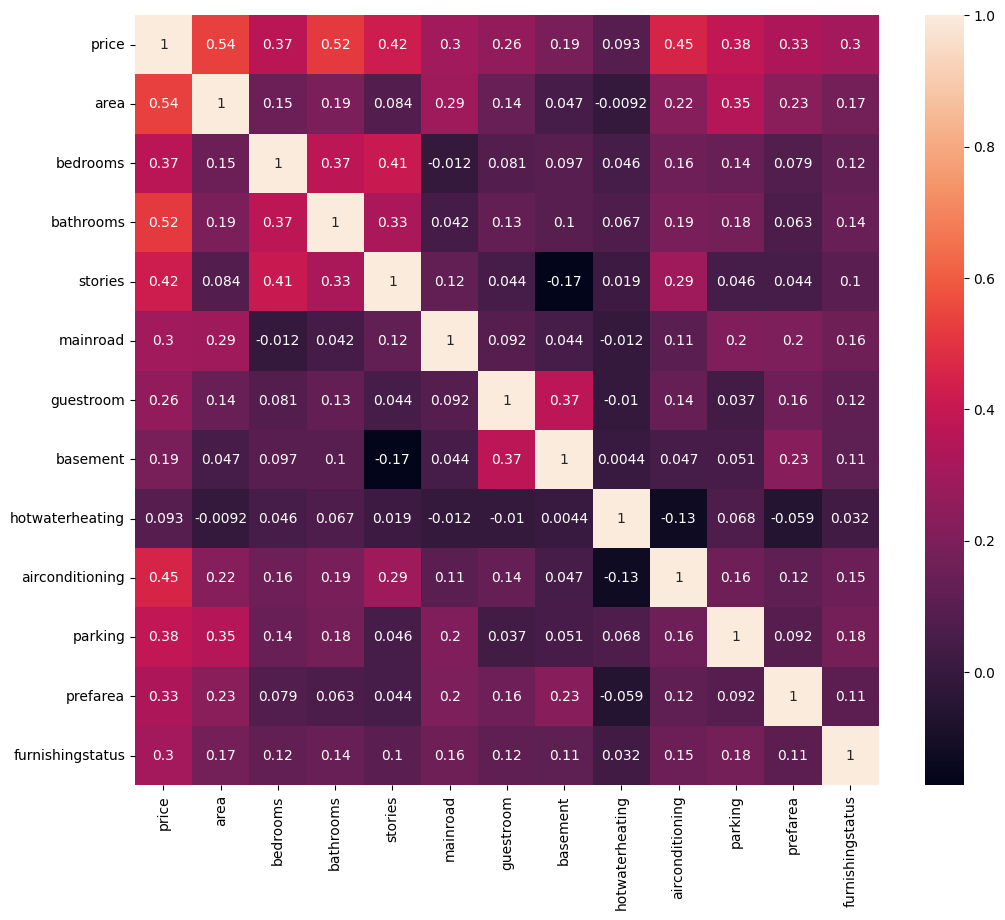

In [50]:
cor = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cor, annot=True)
plt.show()

# Models + log in Mlflow

In [10]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('Python_final_exam_1_year_2_sem')

2026/04/27 16:29:37 INFO mlflow.tracking.fluent: Experiment with name 'Python_final_exam_1_year_2_sem' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/802312507209847770', creation_time=1777289377099, experiment_id='802312507209847770', last_update_time=1777289377099, lifecycle_stage='active', name='Python_final_exam_1_year_2_sem', tags={}, workspace='default'>

In [11]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(data.drop('price', axis=1), data['price'], test_size=0.2, random_state=42)

In [12]:
model_lin = sk.linear_model.LinearRegression()
model_lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model_lin.predict(X_test)

### Metrics:

**Mean Absolute Error (MAE):**
```math
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
```

**Mean Squared Error (MSE):**
```math
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
```
**$R^2$ Score:**
```math
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
```
**Explained Variance Score:** (дисперсия ошибки)
```math
EVS = 1 - \frac{Var(y - \hat{y})}{Var(y)}
```
**Дисперсия:**
```math
Var(X) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2
```


In [14]:
print('Mae:', sk.metrics.mean_absolute_error(y_test, y_pred))
print('Mse:', sk.metrics.mean_squared_error(y_test, y_pred))
print('R2:', sk.metrics.r2_score(y_test, y_pred)) 
print('dispersion:', sk.metrics.explained_variance_score(y_test, y_pred))

Mae: 979679.6912959905
Mse: 1771751116594.036
R2: 0.6494754192267802
dispersion: 0.6533855956667481


In [46]:
def logg(name, y_pred, y_test=y_test):
    with mlflow.start_run(run_name=name):
        mae = sk.metrics.mean_absolute_error(y_test, y_pred)
        mse = sk.metrics.mean_squared_error(y_test, y_pred)
        r2 = sk.metrics.r2_score(y_test, y_pred)
        disper = sk.metrics.explained_variance_score(y_test, y_pred)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("dispersion", disper)
    print(f'Mae {mae}, Mse {mse}, R2 {r2}, dispersion {disper}')

In [16]:
logg('Linear Regression', y_pred)

🏃 View run Linear Regression at: http://localhost:5000/#/experiments/802312507209847770/runs/0782f9664f2744d094d45814f5e87bfc
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 979679.6912959905, Mse 1771751116594.036, R2 0.6494754192267802, dispersion 0.6533855956667481


In [17]:
model_xgb = xgb.XGBRegressor()
model_xgb.fit(X_train, y_train)
logg('XGBoost', model_xgb.predict(X_test))

🏃 View run XGBoost at: http://localhost:5000/#/experiments/802312507209847770/runs/78a20c665d6e407190eb6926115de693
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 1062316.125, Mse 2032404398080.0, R2 0.597907543182373, dispersion 0.6068953275680542


In [18]:
model_lgb = lgb.LGBMRegressor()
model_lgb.fit(X_train, y_train)
logg('LightGBM', model_lgb.predict(X_test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 12
[LightGBM] [Info] Start training from score 4706527.385321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [19]:
model_ridge = sk.linear_model.Ridge()
model_ridge.fit(X_train, y_train)
logg('Ridge Regression', model_ridge.predict(X_test))

🏃 View run Ridge Regression at: http://localhost:5000/#/experiments/802312507209847770/runs/0fb2fc49a7c9412684f7da262b2a9ef7
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 979965.1588028349, Mse 1774250256413.3162, R2 0.6489809875149882, dispersion 0.6529176722808595


In [20]:
model_lasso = sk.linear_model.Lasso()
model_lasso.fit(X_train, y_train)
logg('Lasso Regression', model_lasso.predict(X_test))

🏃 View run Lasso Regression at: http://localhost:5000/#/experiments/802312507209847770/runs/19126e53bdee4e329d5b522bab55d92f
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 979680.6413186704, Mse 1771754701241.8455, R2 0.6494747100373467, dispersion 0.6533848773460795


In [21]:
model_baies = sk.naive_bayes.GaussianNB()
model_baies.fit(X_train, y_train)
logg('Naive Bayes', model_baies.predict(X_test))

🏃 View run Naive Bayes at: http://localhost:5000/#/experiments/802312507209847770/runs/9e31b86afbec49e39c42f8c9dee0919e
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 1166527.5229357798, Mse 2993570149082.569, R2 0.40774981785276065, dispersion 0.44655737705292553


In [22]:
model_forest = sk.ensemble.RandomForestRegressor()
model_forest.fit(X_train, y_train)
logg('Random Forest', model_forest.predict(X_test))

🏃 View run Random Forest at: http://localhost:5000/#/experiments/802312507209847770/runs/afe241654c4e40f594702de79e27b285
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 1022384.8244648319, Mse 1897758050483.0806, R2 0.6245461121348876, dispersion 0.6330337267370718


In [23]:
model_bagging = sk.ensemble.BaggingRegressor()
model_bagging.fit(X_train, y_train)
logg('Bagging', model_bagging.predict(X_test))

🏃 View run Bagging at: http://localhost:5000/#/experiments/802312507209847770/runs/d0f6d1c1fc7e4b799de4770ff984da57
🧪 View experiment at: http://localhost:5000/#/experiments/802312507209847770
Mae 1046649.8256880734, Mse 2127418887750.5046, R2 0.579109838411553, dispersion 0.5906772107965371


In [25]:
model_cat = cb.CatBoostRegressor()
model_cat.fit(X_train, y_train)
logg('CatBoost', model_cat.predict(X_test))

Learning rate set to 0.03591
0:	learn: 1722185.2240597	total: 49.1ms	remaining: 49.1s
1:	learn: 1691228.2966730	total: 49.3ms	remaining: 24.6s
2:	learn: 1662949.6832359	total: 49.6ms	remaining: 16.5s
3:	learn: 1640536.1022960	total: 49.8ms	remaining: 12.4s
4:	learn: 1615578.5702964	total: 50.1ms	remaining: 9.96s
5:	learn: 1590491.4540715	total: 50.3ms	remaining: 8.33s
6:	learn: 1567279.9276120	total: 50.5ms	remaining: 7.17s
7:	learn: 1541347.9285174	total: 50.7ms	remaining: 6.29s
8:	learn: 1518552.4825913	total: 51ms	remaining: 5.61s
9:	learn: 1497662.9761521	total: 51.2ms	remaining: 5.07s
10:	learn: 1476394.3641661	total: 51.4ms	remaining: 4.63s
11:	learn: 1457828.9203213	total: 51.7ms	remaining: 4.25s
12:	learn: 1438586.8123715	total: 51.9ms	remaining: 3.94s
13:	learn: 1419402.6883983	total: 52.1ms	remaining: 3.67s
14:	learn: 1403459.6522483	total: 52.3ms	remaining: 3.44s
15:	learn: 1387895.7289666	total: 52.6ms	remaining: 3.23s
16:	learn: 1371280.7328907	total: 52.8ms	remaining: 3.0

In [34]:
model_cat.tree_count_

1000

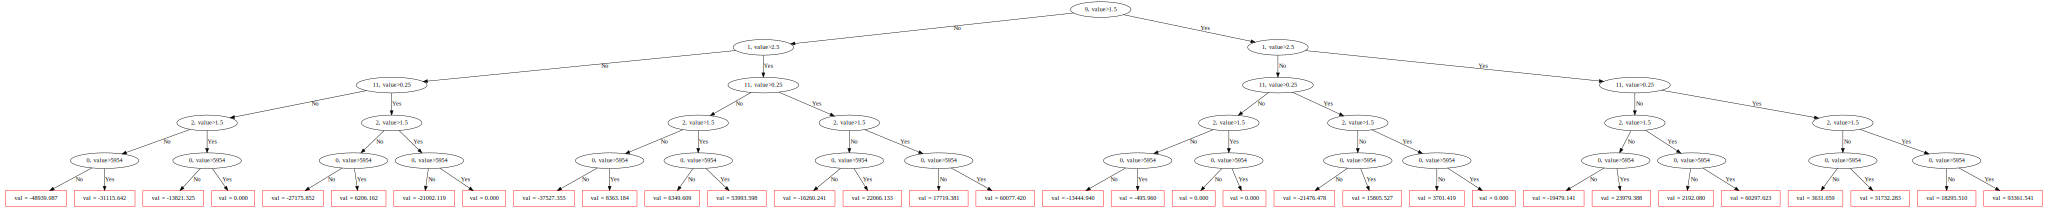

In [35]:
model_cat.plot_tree(5)

In [32]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1.0,0.0,0.0,0.0,1.0,1,0.0,1.0
93,7200,3,2,1,1.0,0.0,1.0,0.0,1.0,3,0.0,0.5
335,3816,2,1,1,1.0,0.0,1.0,0.0,1.0,2,0.0,1.0
412,2610,3,1,2,1.0,0.0,1.0,0.0,0.0,0,1.0,0.0
471,3750,3,1,2,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1.0,0.0,0.0,0.0,1.0,0,0.0,0.0
106,5450,4,2,1,1.0,0.0,1.0,0.0,1.0,0,1.0,0.5
270,4500,3,2,3,1.0,0.0,0.0,1.0,0.0,1,0.0,1.0
435,4040,2,1,1,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0


In [39]:
def model_N(X_train, y_train):
    model_nn = keras.Sequential()
    model_nn.add(keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model_nn.add(keras.layers.Dense(32, activation='relu'))
    model_nn.add(keras.layers.Dense(1))
    model_nn.compile(optimizer='adam', loss='mean_squared_error')
    model_nn.fit(X_train, y_train, epochs=100)
    return model_nn


In [41]:
logg('Neural Network_without data Normalized', model_N(X_train, y_train).predict(X_test))

Epoch 1/100


/home/alexseyka/.venvs/jupyter/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25233880776704.0000  
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25222407258112.0000 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25211711782912.0000 
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25199298740224.0000 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25182083219456.0000 
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25158226018304.0000 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25125948751872.0000 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25082590134272.0000 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25025881047040.0000 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24954080854016.0000 
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24862452088832.0000 
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24753786060800.0000 
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

In [42]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1.0,0.0,0.0,0.0,1.0,1,0.0,1.0
93,7200,3,2,1,1.0,0.0,1.0,0.0,1.0,3,0.0,0.5
335,3816,2,1,1,1.0,0.0,1.0,0.0,1.0,2,0.0,1.0
412,2610,3,1,2,1.0,0.0,1.0,0.0,0.0,0,1.0,0.0
471,3750,3,1,2,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1.0,0.0,0.0,0.0,1.0,0,0.0,0.0
106,5450,4,2,1,1.0,0.0,1.0,0.0,1.0,0,1.0,0.5
270,4500,3,2,3,1.0,0.0,0.0,1.0,0.0,1,0.0,1.0
435,4040,2,1,1,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0


In [43]:
x_s = sk.preprocessing.StandardScaler()
y_s = sk.preprocessing.StandardScaler()
X_train_n = x_s.fit_transform(X_train)
X_test_n = x_s.transform(X_test)
y_train_n = y_s.fit_transform(y_train.values.reshape(-1, 1))
y_test_n = y_s.transform(y_test.values.reshape(-1, 1))

In [49]:
X_train_n

array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032,  0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032,  1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.07931697]])

In [47]:
model = model_N(X_train_n, y_train_n)

y_pred_n = model.predict(X_test_n)

y_pred = y_s.inverse_transform(y_pred_n.reshape(-1, 1)).ravel()
y_true = y_s.inverse_transform(y_test_n.reshape(-1, 1)).ravel()

logg('Neural Network with data Normalized', y_pred, y_test=y_true)

Epoch 1/100


/home/alexseyka/.venvs/jupyter/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0252  
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5270 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3748 
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3302 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3003 
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2831 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2712 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2595 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2501 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2425 
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2358 
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2269 
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2151 
Epoch 15/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2072 


![results.png](docs/results.png)

In [56]:
joblib.dump(model_lin, "linear_model.joblib")

['linear_model.joblib']